In [ ]:
pip install torch torchvision timm tqdm scikit-learn

In [ ]:
from torchvision import datasets
'''
DATA_ROOT = "/content/drive/MyDrive/NutriSense/Dataset"

train_dataset = datasets.Food101(
    root=DATA_ROOT,
    split="train",
    transform=train_transforms,
    download=False
)

test_dataset = datasets.Food101(
    root=DATA_ROOT,
    split="test",
    transform=test_transforms,
    download=False
)
'''

'\nDATA_ROOT = "/content/drive/MyDrive/NutriSense/Dataset"\n\ntrain_dataset = datasets.Food101(\n    root=DATA_ROOT,\n    split="train",\n    transform=train_transforms,\n    download=False\n)\n\ntest_dataset = datasets.Food101(\n    root=DATA_ROOT,\n    split="test",\n    transform=test_transforms,\n    download=False\n)\n'

In [ ]:
from torch.utils.data import DataLoader
'''
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)
print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
print("Classes:", len(train_dataset.classes))
'''

'\ntrain_loader = DataLoader(\n    train_dataset,\n    batch_size=BATCH_SIZE,\n    shuffle=True,\n    num_workers=NUM_WORKERS,\n    pin_memory=True\n)\n\ntest_loader = DataLoader(\n    test_dataset,\n    batch_size=BATCH_SIZE,\n    shuffle=False,\n    num_workers=NUM_WORKERS,\n    pin_memory=True\n)\nprint("Train samples:", len(train_dataset))\nprint("Test samples:", len(test_dataset))\nprint("Classes:", len(train_dataset.classes))\n'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import copy
import time
import random
import numpy as np
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import timm
from sklearn.metrics import accuracy_score, classification_report


# =========================
# 1) Settings
# =========================
DATA_ROOT = "./data"
BATCH_SIZE = 64
NUM_EPOCHS = 20
LR = 1e-4
WEIGHT_DECAY = 1e-4
IMG_SIZE = 224
NUM_WORKERS = 2
MODEL_NAME = "swin_tiny_patch4_window7_224.ms_in1k"
SAVE_PATH = "best_swin_food101.pth"
SEED = 42

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# =========================
# 2) Reproducibility
# =========================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


# =========================
# 3) Transforms
# =========================
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# =========================
# 4) Load Food-101
# =========================
train_dataset = datasets.Food101(
    root=DATA_ROOT,
    split="train",
    transform=train_transforms,
    download=True
)

test_dataset = datasets.Food101(
    root=DATA_ROOT,
    split="test",
    transform=test_transforms,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

class_names = train_dataset.classes
num_classes = len(class_names)

print(f"Number of classes: {num_classes}")
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples : {len(test_dataset)}")


# =========================
# 5) Build Swin Transformer
# =========================
model = timm.create_model(
    MODEL_NAME,
    pretrained=True,
    num_classes=num_classes
)

model = model.to(DEVICE)


# =========================
# 6) Loss / Optimizer / Scheduler
# =========================
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    model.parameters(),
    lr=LR,
    weight_decay=WEIGHT_DECAY
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS
)


# =========================
# 7) Train one epoch
# =========================
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Training", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc


# =========================
# 8) Evaluate
# =========================
@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Evaluating", leave=False):
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)

        preds = torch.argmax(outputs, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)
    return epoch_loss, epoch_acc, all_labels, all_preds


# =========================
# 9) Full training loop
# =========================
best_acc = 0.0
best_model_wts = copy.deepcopy(model.state_dict())

history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": []
}

start_time = time.time()

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, DEVICE
    )

    test_loss, test_acc, y_true, y_pred = evaluate(
        model, test_loader, criterion, DEVICE
    )

    scheduler.step()

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Test  Loss: {test_loss:.4f} | Test  Acc: {test_acc:.4f}")

    if test_acc > best_acc:
        best_acc = test_acc
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), SAVE_PATH)
        print(f"Best model saved to: {SAVE_PATH}")

total_time = time.time() - start_time
print(f"\nTraining completed in {total_time/60:.2f} minutes")
print(f"Best Test Accuracy: {best_acc:.4f}")


# =========================
# 10) Load best model and final report
# =========================
model.load_state_dict(best_model_wts)

test_loss, test_acc, y_true, y_pred = evaluate(
    model, test_loader, criterion, DEVICE
)

print("\nFinal Classification Report:")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


100%|██████████| 5.00G/5.00G [04:06<00:00, 20.3MB/s]


Number of classes: 101
Train samples: 75750
Test samples : 25250


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


Epoch [1/20]
----------------------------------------


...

Train Loss: 0.0297 | Train Acc: 0.9926
Test  Loss: 0.5295 | Test  Acc: 0.8864

Epoch [18/20]
----------------------------------------


Train Loss: 0.0259 | Train Acc: 0.9942
Test  Loss: 0.5276 | Test  Acc: 0.8876
Best model saved to: best_swin_food101.pth

Epoch [19/20]
----------------------------------------


Train Loss: 0.0246 | Train Acc: 0.9944
Test  Loss: 0.5248 | Test  Acc: 0.8887
Best model saved to: best_swin_food101.pth

Epoch [20/20]
----------------------------------------


Train Loss: 0.0237 | Train Acc: 0.9946
Test  Loss: 0.5234 | Test  Acc: 0.8887

Training completed in 403.54 minutes
Best Test Accuracy: 0.8887



Final Classification Report:
                         precision    recall  f1-score   support

              apple_pie     0.7500    0.7320    0.7409       250
         baby_back_ribs     0.8954    0.8560    0.8753       250
                baklava     0.9073    0.9400    0.9234       250
         beef_carpaccio     0.9173    0.9320    0.9246       250
           beef_tartare     0.8377    0.8880    0.8621       250
             beet_salad     0.8427    0.8360    0.8394       250
               beignets     0.9231    0.9120    0.9175       250
               bibimbap     0.9590    0.9360    0.9474       250
          bread_pudding     0.7409    0.7320    0.7364       250
      breakfast_burrito     0.8684    0.7920    0.8285       250
             bruschetta     0.8621    0.8000    0.8299       250
           caesar_salad     0.8949    0.9200    0.9073       250
                cannoli     0.9442    0.9480    0.9461       250
          caprese_salad     0.8902    0.9080    0.8990     

In [ ]:
# =========================================================
# خلية مستقلة: حفظ أوزان موديل الـ 64 باتش الجديد في الدرايف
# =========================================================
import os
import torch

# 1) تحديد مسار مجلد Models مع اسم ملف مميز وجديد يعبر عن الـ 64 باتش
save_path = "/content/drive/MyDrive/Mytraining/Copy of NutriSense/Models/swin_food101_64batch_20epochs.pth"

# 2) التأكد من أن المجلد موجود في الدرايف، وإذا مش موجود يتم إنشاؤه تلقائياً
folder_path = os.path.dirname(save_path)
if not os.path.exists(folder_path):
    os.makedirs(folder_path, exist_ok=True)
    print(f"📁 تم إنشاء المجلد الجديد في الدرايف: {folder_path}")

# 3) أمر الحفظ الفوري والأمن للأوزان
try:
    # نقوم بحفظ الـ state_dict الخاص بالموديل
    torch.save(model.state_dict(), save_path)
    print("\n" + "="*60)
    print(f"✅ ألف مبروك فداء! تم حفظ الموديل الجديد بنجاح في ملف مستقل!")
    print(f"📂 مسار الملف في الدرايف: {save_path}")
    print("="*60)
except NameError:
    print("⚠️ خطأ: تأكدي من تشغيل خلية التدريب أولاً وأن الموديل معرف باسم 'model'.")
except Exception as e:
    print(f"⚠️ حدث خطأ أثناء الحفظ: {e}")

📁 تم إنشاء المجلد الجديد في الدرايف: /content/drive/MyDrive/Mytraining/Copy of NutriSense/Models

✅ ألف مبروك فداء! تم حفظ الموديل الجديد بنجاح في ملف مستقل!
📂 مسار الملف في الدرايف: /content/drive/MyDrive/Mytraining/Copy of NutriSense/Models/swin_food101_64batch_20epochs.pth


In [ ]:
#!cp -r /content/data/food-101 /content/drive/MyDrive/NutriSense/Dataset/

In [ ]:
!cp best_swin_food101.pth /content/drive/MyDrive/NutriSense/Models/best_swin_food101-20epoch.pth

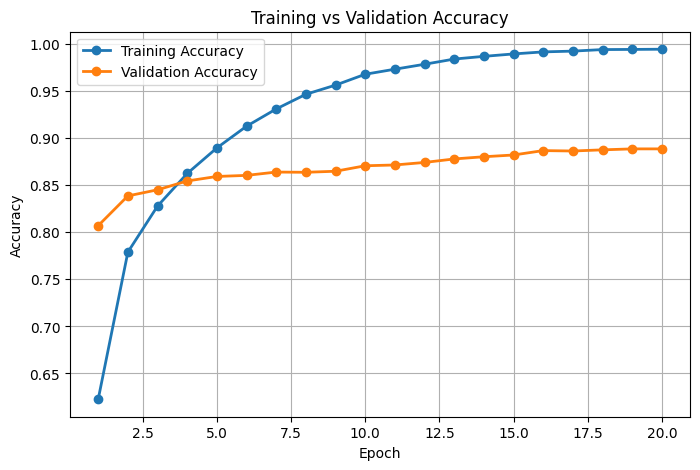

In [ ]:
import matplotlib.pyplot as plt

epochs = range(1, len(history["train_acc"]) + 1)

plt.figure(figsize=(8,5))

plt.plot(epochs, history["train_acc"],
         marker='o', linewidth=2, label="Training Accuracy")

plt.plot(epochs, history["test_acc"],
         marker='o', linewidth=2, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

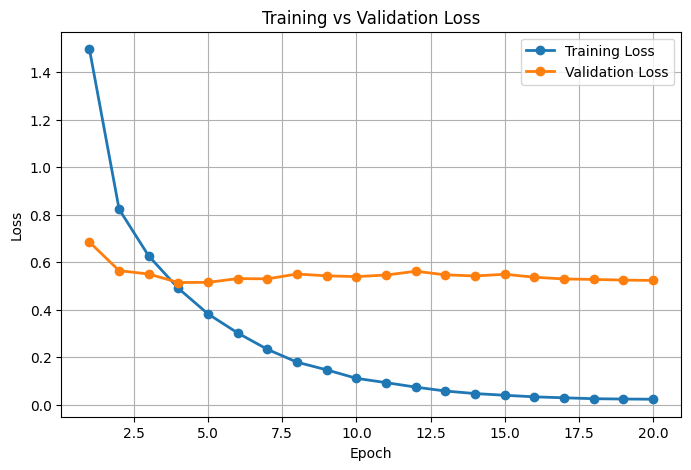

In [ ]:
plt.figure(figsize=(8,5))

plt.plot(epochs, history["train_loss"],
         marker='o', linewidth=2, label="Training Loss")

plt.plot(epochs, history["test_loss"],
         marker='o', linewidth=2, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()


In [ ]:
!pip install grad-cam shap opencv-python matplotlib


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 101.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=70b62e15e9e3add84cfb3e2373dfec6bcb65a7e1ba91c1ae0783cc429664c7b6
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image


**1) كود Grad-CAM مع Swin Transformer**

أضيفي هذا الجزء بعد نهاية التدريب وبعد تحميل أفضل وزن للمودل.

**دالة reshape_transform الخاصة بـ Swin**

في Swin المخرجات ليست feature maps مباشرة مثل CNN، لذلك نعيد تشكيلها:

In [ ]:
def reshape_transform(tensor, height=7, width=7):
    """
    تجعل الخرج مناسبًا لـ Grad-CAM سواء كان:
    [B, N, C] أو [B, H, W, C]
    """

    if len(tensor.shape) == 3:
        # الشكل [B, N, C]
        result = tensor.reshape(tensor.size(0), height, width, tensor.size(2))
        result = result.permute(0, 3, 1, 2)
        return result

    elif len(tensor.shape) == 4:
        # الشكل [B, H, W, C]
        result = tensor.permute(0, 3, 1, 2)
        return result

    else:
        raise ValueError(f"Unexpected tensor shape: {tensor.shape}")


**اختيار الطبقة المستهدفة**

في Swin Tiny غالبًا نأخذ آخر بلوك:

In [ ]:
target_layer = model.layers[-1].blocks[-1].norm1


**إنشاء Grad-CAM**

In [ ]:
cam = GradCAM(
    model=model,
    target_layers=[target_layer],
    reshape_transform=reshape_transform
)

**دالة لعرض النتيجة على صورة من test_dataset**

In [ ]:
def denormalize(img_tensor, mean, std):
    img = img_tensor.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    img = np.clip(img, 0, 1)
    return img

def show_gradcam_for_sample(dataset, index):
    model.eval()

    image_tensor, label = dataset[index]
    input_tensor = image_tensor.unsqueeze(0).to(DEVICE)

    output = model(input_tensor)
    pred = torch.argmax(output, dim=1).item()

    grayscale_cam = cam(input_tensor=input_tensor)[0]

    rgb_img = denormalize(
        image_tensor,
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )

    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(rgb_img)
    plt.title(f"Original\nTrue: {class_names[label]}\nPred: {class_names[pred]}")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(visualization)
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.tight_layout()
    plt.show()


**مثال للاستخدام**

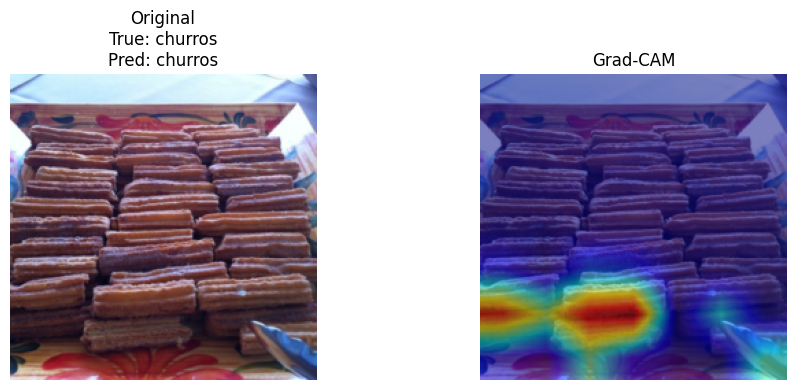

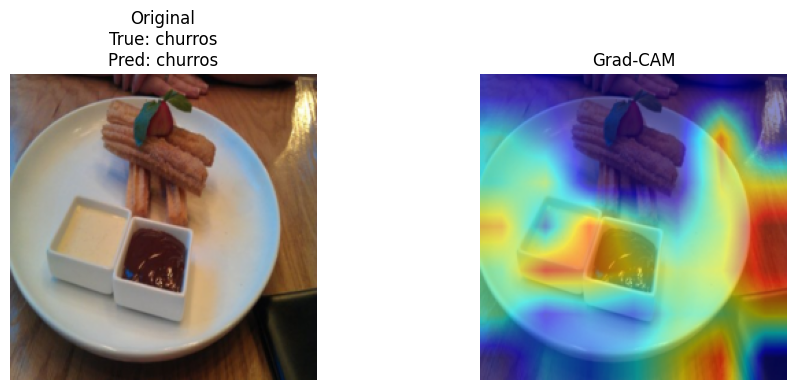

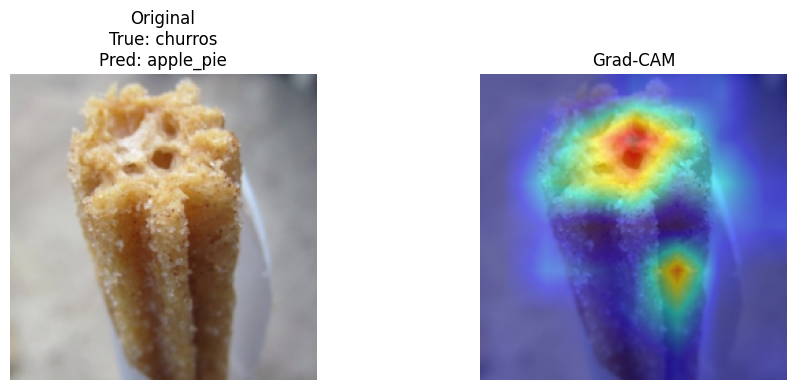

In [ ]:
show_gradcam_for_sample(test_dataset, 0)
show_gradcam_for_sample(test_dataset, 10)
show_gradcam_for_sample(test_dataset, 25)


In [ ]:
import matplotlib.pyplot as plt

def show_different_food_types(dataset, class_names, num_types=20):
    shown_classes = set()
    selected_samples = []

    for i in range(len(dataset)):
        image_tensor, label = dataset[i]

        if label not in shown_classes:
            shown_classes.add(label)
            selected_samples.append((image_tensor, label))

        if len(selected_samples) == num_types:
            break

    cols = 4
    rows = (num_types + cols - 1) // cols

    plt.figure(figsize=(16, 4 * rows))

    for idx, (image_tensor, label) in enumerate(selected_samples):
        # إلغاء الـ normalization للعرض
        img = image_tensor.clone().cpu().numpy().transpose(1, 2, 0)
        img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
        img = img.clip(0, 1)

        plt.subplot(rows, cols, idx + 1)
        plt.imshow(img)
        plt.title(class_names[label], fontsize=10)
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
show_different_food_types(test_dataset, class_names, num_types=20)


In [ ]:
def show_gradcam_for_20_types(dataset, class_names, num_types=20):
    shown_classes = set()
    selected_indices = []

    for i in range(len(dataset)):
        _, label = dataset[i]
        if label not in shown_classes:
            shown_classes.add(label)
            selected_indices.append(i)
        if len(selected_indices) == num_types:
            break

    for idx in selected_indices:
        show_gradcam_for_sample(dataset, idx)


In [ ]:
show_gradcam_for_20_types(test_dataset, class_names, num_types=20)
